# Phân Tích Quyết Định Của Engine Khắc Phục Sự Cố

Notebook này không phải là EDA. Mỗi biểu đồ được xây dựng nhằm trả lời một câu hỏi về lý do engine đưa ra quyết định: vì sao chọn hành động này, vì sao chọn ngưỡng này, hoặc vì sao một sự cố bị gán là ngoài phân phối (OOD - Out-of-Distribution).

Notebook thực thi engine thực tế trên các tiến trình E01–E08 và sử dụng kho dữ liệu sự cố lịch sử để phân tích, giải thích các quyết định được đưa ra.

In [1]:
import json, glob
from pathlib import Path
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

import retrieval as ret
import decision as dec
import engine as eng

HISTORY = json.loads(Path('incidents_history.json').read_text(encoding='utf-8'))
ACTIONS = dec.load_actions('actions.yaml')

# Chay engine tren moi su co eval, trong tien trinh, va giu lai noi dung chi tiet.
runs = {}
for path in sorted(glob.glob('eval/E*.json')):
    eid = Path(path).stem
    if not eid.startswith('E'):
        continue
    runs[eid] = eng.decide(Path(path), Path('incidents_history.json'), Path('actions.yaml'))
eids = list(runs.keys())
print('Da chay:', eids)

Da chay: ['E01', 'E02', 'E03', 'E04', 'E05', 'E06', 'E07', 'E08']


## Phần 1 - Tổng quan tập dữ liệu

Câu hỏi đặt ra là: *engine bỏ phiếu dựa trên những dữ liệu nào?*

Kho dữ liệu lịch sử khá nhỏ (chỉ **29 sự cố**) và bị mất cân bằng khi hành động **`page_oncall`** chiếm tỷ lệ áp đảo. Đây chính là lý do việc đánh giá kết quả bỏ phiếu và cơ chế xử lý **OOD (Out-of-Distribution)** trở nên rất quan trọng.

Nếu chỉ dựa vào tần suất xuất hiện trong dữ liệu lịch sử, engine sẽ có xu hướng ưu tiên **`page_oncall`** cho phần lớn tình huống. Nói cách khác, đa số tiền lệ trong kho dữ liệu đều cho thấy rằng *“con người đã phải can thiệp để xử lý sự cố”*, thay vì hệ thống tự động thực hiện một hành động khắc phục cụ thể.


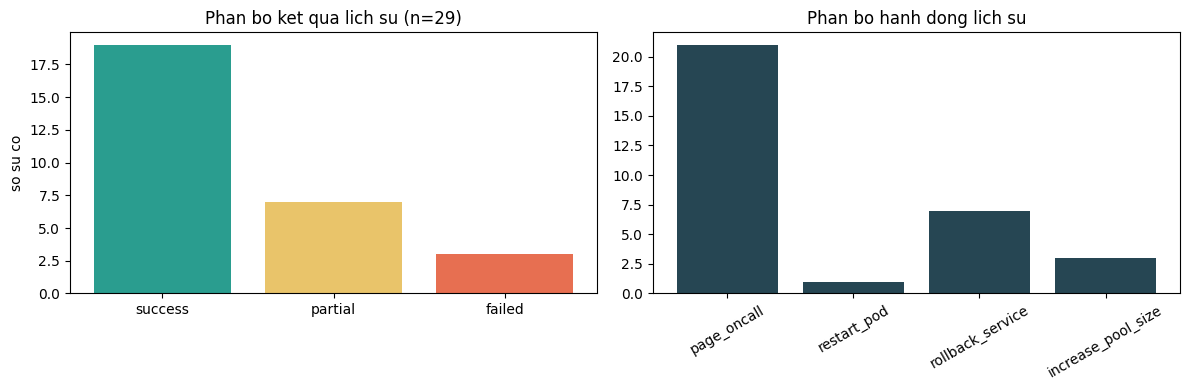

ket qua: {'success': 19, 'partial': 7, 'failed': 3}
hanh dong: {'page_oncall': 21, 'restart_pod': 1, 'rollback_service': 7, 'increase_pool_size': 3}


In [2]:
outcomes = Counter(h['outcome'] for h in HISTORY)
action_names = Counter()
for h in HISTORY:
    for a in h['actions_taken']:
        action_names[a.split(':')[0]] += 1
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].bar(outcomes.keys(), outcomes.values(), color=['#2a9d8f','#e9c46a','#e76f51'])
ax[0].set_title('Phan bo ket qua lich su (n=%d)' % len(HISTORY)); ax[0].set_ylabel('so su co')
ax[1].bar(action_names.keys(), action_names.values(), color='#264653')
ax[1].set_title('Phan bo hanh dong lich su'); ax[1].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()
print('ket qua:', dict(outcomes)); print('hanh dong:', dict(action_names))

Khoảng 65% tiền lệ trong dữ liệu lịch sử có kết quả thành công (success), nhưng page_oncall lại là hành động xuất hiện nhiều nhất. Điều này tạo ra rủi ro rằng một thuật toán láng giềng gần nhất (nearest neighbor) đơn giản sẽ có xu hướng đề xuất gọi người trực quá thường xuyên chỉ vì đó là hành động phổ biến trong dữ liệu.

Để tránh thiên lệch này, engine không chỉ sao chép hành động từ các tiền lệ gần nhất. Thay vào đó, hệ thống tái định hướng (re-rank) các tiền lệ theo mức độ liên quan đến service gốc đang gặp sự cố, giúp ưu tiên những trường hợp thực sự tương đồng về ngữ cảnh vận hành.

Kết quả cuối cùng được quyết định thông qua cơ chế bỏ phiếu giữa các tiền lệ phù hợp, thay vì dựa trên tần suất xuất hiện của một hành động trong toàn bộ kho dữ liệu. Vì vậy, hành động page_oncall chỉ được chọn khi kết quả bỏ phiếu cho thấy đó là phương án hợp lý nhất đối với sự cố hiện tại, chứ không đơn thuần vì nó là hành động phổ biến nhất trong lịch sử.

## Phần 2 - Phân Tích Truy Hồi

Câu hỏi: *Sự cố quá khứ nào đủ gần để tin cậy, và ranh giới OOD nằm ở đâu?* Ta vẽ độ tương đồng hợp nhất (fused similarity) của láng giềng gần nhất cho mỗi sự cố, so với ngưỡng OOD là 0.30.

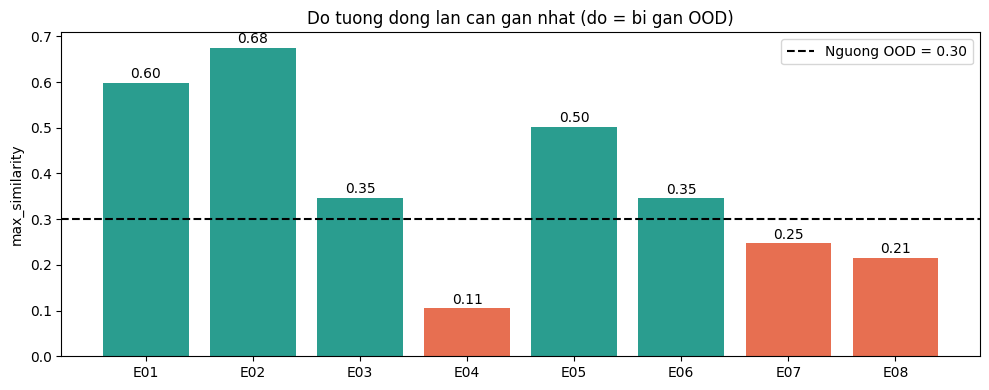

In [3]:
maxsims = [runs[e]['evidence']['max_similarity'] for e in eids]
oods = [runs[e]['evidence']['ood'] for e in eids]
colors = ['#e76f51' if o else '#2a9d8f' for o in oods]
plt.figure(figsize=(10,4))
plt.bar(eids, maxsims, color=colors)
plt.axhline(0.30, color='k', ls='--', label='Nguong OOD = 0.30')
for i,s in enumerate(maxsims): plt.text(i, s+0.01, f'{s:.2f}', ha='center')
plt.title('Do tuong dong lan can gan nhat (do = bi gan OOD)')
plt.ylabel('max_similarity'); plt.legend(); plt.tight_layout(); plt.show()

Có một khoảng cách rõ ràng giữa E03 (0.347, được giữ lại) và E07 (0.247, gần ngưỡng). E01, E02 và E05 là các trường hợp khớp với độ tin cậy cao; trong khi E04, E07 và E08 nằm ở phía dưới ngưỡng. Đây là bằng chứng hỗ trợ cho việc lựa chọn ngưỡng OOD là 0.30 (FINDINGS Q1 / Tùy chọn A).

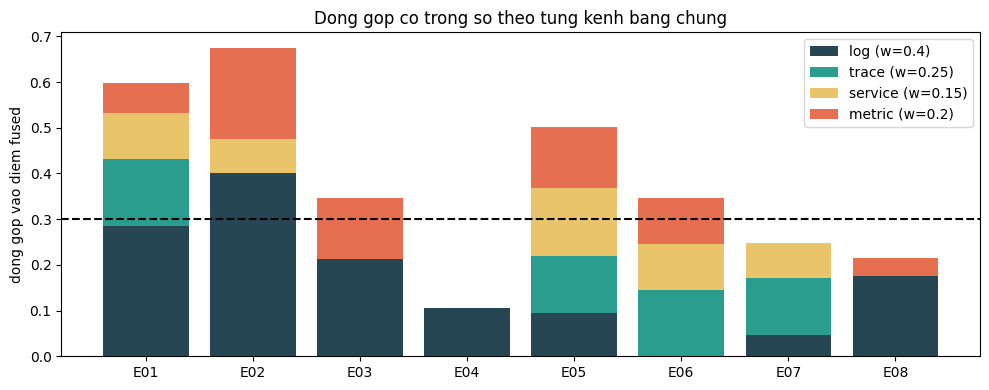

In [4]:
chans = ['log','trace','service','metric']
M = np.array([[runs[e]['evidence']['top_neighbors'][0]['breakdown'][c] for c in chans] for e in eids])
w = [ret.W_LOG, ret.W_TRACE, ret.W_SERVICE, ret.W_METRIC]
palette = ['#264653','#2a9d8f','#e9c46a','#e76f51']
plt.figure(figsize=(10,4)); bottom = np.zeros(len(eids))
for j,c in enumerate(chans):
    plt.bar(eids, M[:,j]*w[j], bottom=bottom, label=f'{c} (w={w[j]})', color=palette[j]); bottom += M[:,j]*w[j]
plt.axhline(0.30, color='k', ls='--')
plt.title('Dong gop co trong so theo tung kenh bang chung'); plt.ylabel('dong gop vao diem fused')
plt.legend(); plt.tight_layout(); plt.show()

Cột của E03 được nâng lên nhờ **log + metric** (láng giềng sự cố memory leak không có trace), trong khi giá trị thấp của E07 chủ yếu đến từ **trace + service** nhưng gần như không có sự tương đồng về log. Đây chỉ là một sự trùng khớp về topology. Việc đặt trọng số cho **log** và **metric** cao hơn **trace** và **service** giúp giữ lại các trường hợp khớp thực sự ở phía trên ngưỡng, đồng thời loại bỏ các trường hợp trùng khớp ngẫu nhiên ở phía dưới ngưỡng.


## Phan 3 - Phân tích bỏ phiếu

Câu hỏi: Vì sao hành động này giành chiến thắng? Biểu đồ thể hiện kết quả bỏ phiếu theo công thức (similarity × outcome_weight) cho sự cố hòa E05 và sự cố "log nói dối" E06.

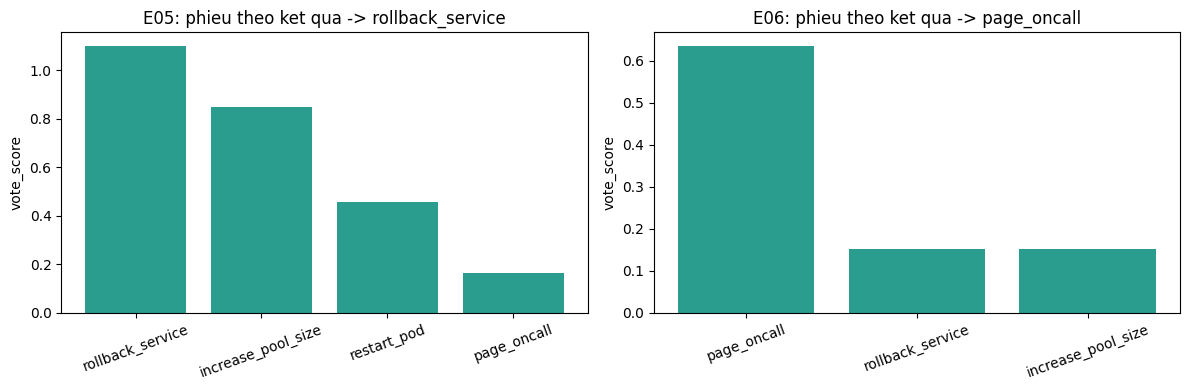

E05 [('rollback_service', 1.102), ('increase_pool_size', 0.8508), ('restart_pod', 0.4554), ('page_oncall', 0.1652)]
E06 [('page_oncall', 0.6358), ('rollback_service', 0.1508), ('increase_pool_size', 0.1508)]


In [5]:
def vote_plot(eid):
    cands = runs[eid]['evidence']['candidate_actions']
    names = [c['name'] for c in cands]; scores = [c['vote_score'] for c in cands]
    plt.bar(names, scores, color=['#2a9d8f' if s>=0 else '#e76f51' for s in scores])
    plt.title(f'{eid}: phieu theo ket qua -> {runs[eid]["selected_action"]}')
    plt.ylabel('vote_score'); plt.xticks(rotation=20)
plt.figure(figsize=(12,4))
plt.subplot(1,2,1); vote_plot('E05'); plt.subplot(1,2,2); vote_plot('E06')
plt.tight_layout(); plt.show()
for e in ('E05','E06'): print(e, [(c['name'], c['vote_score']) for c in runs[e]['evidence']['candidate_actions']])

**(E05):** Hai láng giềng có độ tương đồng ngang nhau (0.5025), nhưng tiền lệ có kết quả `partial` bị chiết khấu bởi trọng số kết quả chỉ còn khoảng một nửa. Vì vậy, `rollback_service` đạt điểm bỏ phiếu 1.10 và vượt qua `restart_pod` với 0.46.

**(E06):** Tiền lệ duy nhất ủng hộ `rollback_service` xuất phát từ log *“nói dối”* của `payment-svc` và chỉ đóng góp khoảng 0.15 điểm. Trong khi đó, các tiền lệ liên quan đến `cart-svc` được hỗ trợ bởi dữ liệu trace đã đẩy điểm của `page_oncall` lên 0.64. Do đó, engine chọn gọi người trực thay vì tự động rollback nhầm service.


## Phần 4 - Phân tích quyết định

Câu hỏi: Chi phí và blast radius có làm thay đổi quyết định hay không, và engine có đang quá liều lĩnh? 
Bên trái: sự thay đổi từ confidence sang utility sau khi áp dụng các yếu tố chi phí và rủi ro cho các ứng viên của E01. 
Bên phải: mối quan hệ giữa confidence và blast radius của từng quyết định cuối cùng, kèm theo vùng an toàn được xác định trước.

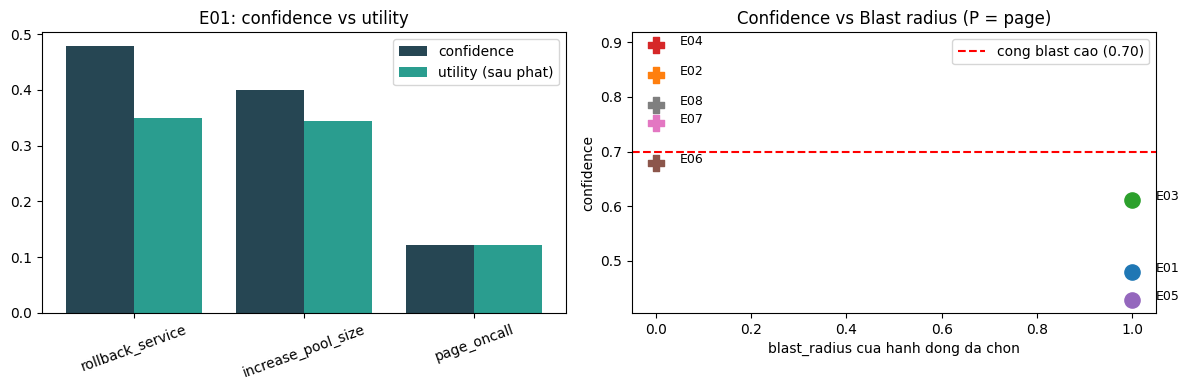

In [6]:
cands = runs['E01']['evidence']['candidate_actions']
names = [c['name'] for c in cands]; conf = [c['confidence'] for c in cands]
util = [dec.utility(c['confidence'], ACTIONS.get(c['name'], {})) for c in cands]
x = range(len(names))
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.bar([i-0.2 for i in x], conf, width=0.4, label='confidence', color='#264653')
plt.bar([i+0.2 for i in x], util, width=0.4, label='utility (sau phat)', color='#2a9d8f')
plt.xticks(list(x), names, rotation=20); plt.title('E01: confidence vs utility'); plt.legend()
plt.subplot(1,2,2)
for e in eids:
    m = ACTIONS.get(runs[e]['selected_action'], {}); br = m.get('blast_radius_services',0); cf = runs[e]['confidence']
    plt.scatter(br, cf, s=120, marker=('P' if runs[e]['selected_action']=='page_oncall' else 'o'))
    plt.text(br+0.05, cf, e, fontsize=9)
plt.axhline(0.70, color='r', ls='--', label='cong blast cao (0.70)')
plt.xlabel('blast_radius cua hanh dong da chon'); plt.ylabel('confidence')
plt.title('Confidence vs Blast radius (P = page)'); plt.legend(); plt.tight_layout(); plt.show()

**Đọc hiểu:** Với E01, `increase_pool_size` có chi phí thấp nên gần vượt qua `rollback_service`, dù `rollback_service` có confidence cao hơn. Sau khi tính utility, hai hành động đạt điểm rất sát nhau (0.344 so với 0.349), cho thấy đây là một sự đánh đổi thực sự và cả hai phương án đều hợp lý.

Ở biểu đồ bên phải, tất cả các hành động tự động được thực thi đều có blast radius bằng 1. Không có hành động nào có blast radius cao được lựa chọn khi confidence còn thấp. Điều này cho thấy cơ chế bảo vệ ở Layer 3 đang hoạt động đúng như thiết kế.


## Phan 5 - Phân tích OOD

Câu hỏi: Vì sao sự cố này bị xem là OOD? Ta quét nhiều mức ngưỡng khác nhau và đặt hai sự cố bị leo thang do OOD (E07, E08) bên cạnh trường hợp khớp sát ranh giới nhưng vẫn được giữ lại (E03).

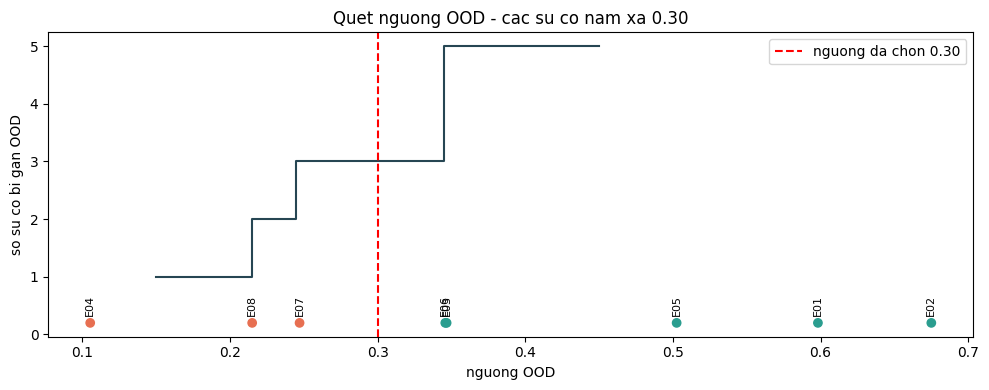

Tai 0.30 - OOD: ['E04', 'E07', 'E08']


In [7]:
sweep = np.linspace(0.15, 0.45, 31)
curve = [sum(1 for e in eids if runs[e]['evidence']['max_similarity'] < th) for th in sweep]
plt.figure(figsize=(10,4))
plt.step(sweep, curve, where='mid', color='#264653')
plt.axvline(0.30, color='r', ls='--', label='nguong da chon 0.30')
plt.scatter(maxsims, [0.2]*len(eids), c=colors, zorder=5)
for e,s in zip(eids,maxsims): plt.text(s, 0.35, e, rotation=90, fontsize=8, ha='center')
plt.xlabel('nguong OOD'); plt.ylabel('so su co bi gan OOD')
plt.title('Quet nguong OOD - cac su co nam xa 0.30'); plt.legend(); plt.tight_layout(); plt.show()
print('Tai 0.30 - OOD:', [e for e in eids if runs[e]['evidence']['ood']])

Số lượng sự cố bị phân loại là OOD thay đổi mạnh trong khoảng ngưỡng 0.25–0.34, cho thấy ngưỡng được chọn nằm trong vùng ổn định và kết quả không quá nhạy với giá trị chính xác. E07 (0.247) và E08 (0.215) là các sự cố bất thường: service gốc inventory-svc gặp lỗi Kubernetes informer, còn t24-service là sự cố dạng cascade; cả hai đều không có hoặc có rất ít tiền lệ tương đồng trong corpus. Ngược lại, E03 (0.347) là trường hợp khớp thực sự với sự cố rò rỉ bộ nhớ và được giữ lại ngay phía trên ngưỡng. Đây là lý do E07 và E08 được xử lý theo hướng OOD và chuyển thành page_oncall, trong khi E03 vẫn được phép thực hiện hành động tự động.